# Notebook 04 — Embeddings & Vocabulary Coverage (Stages 7–8)

Diagnostics for the FastText model (Stage 7) and the aligned embedding matrix (Stage 8).

| Section | Topic |
|---------|-------|
| **A** | Setup, paths, config hash verification |
| **B** | FastText model introspection |
| **C** | Embedding matrix coverage & OOV analysis |
| **D** | Token fertility (avg BPE tokens/word) |
| **E** | Nearest-neighbour sanity checks |
| **F** | UNK forensics |
| **G** | Stage 8 stats JSON summary |

In [1]:
# === SETUP ===
import json, math, random, warnings
from collections import Counter
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('/opt/app-root/src/nlp-chatbot-project-v2.0')
ARTIFACT_DIR = PROJECT_ROOT / 'artifacts'

# --- paths ---
SPM_PATH      = ARTIFACT_DIR / 'stage5_spm.model'
FT_PATH       = ARTIFACT_DIR / 'stage7_fasttext.model'
MATRIX_PATH   = ARTIFACT_DIR / 'stage8_embedding_matrix.npy'
S8_STATS_PATH = ARTIFACT_DIR / 'stage8_stats.json'
TRAIN_JSONL   = ARTIFACT_DIR / 'stage6_train_ids.jsonl'
VAL_JSONL     = ARTIFACT_DIR / 'stage6_val_ids.jsonl'
VIZ_DIR       = PROJECT_ROOT / 'notebooks' / 'visualizations'
VIZ_DIR.mkdir(parents=True, exist_ok=True)

def check(path, label):
    ok = path.exists()
    size = f'{path.stat().st_size/1e6:.1f} MB' if ok else 'MISSING'
    icon = '✓' if ok else '✗'
    print(f'  {icon}  {label:<40} {size}')
    return ok

print('Artifact inventory:')
for label, path in [
    ('SPM model',            SPM_PATH),
    ('FastText model',       FT_PATH),
    ('Embedding matrix',     MATRIX_PATH),
    ('Stage 8 stats',        S8_STATS_PATH),
    ('Stage 6 train JSONL',  TRAIN_JSONL),
    ('Stage 6 val JSONL',    VAL_JSONL),
]:
    check(path, label)

Artifact inventory:
  ✓  SPM model                                0.5 MB
  ✓  FastText model                           38.8 MB
  ✓  Embedding matrix                         19.2 MB
  ✓  Stage 8 stats                            0.0 MB
  ✓  Stage 6 train JSONL                      464.0 MB
  ✓  Stage 6 val JSONL                        20.5 MB


In [2]:
# Section A — Config hash stamps
print('Config-hash stamps (D-1 fix):')
for stage in range(1, 9):
    p = ARTIFACT_DIR / f'.stage{stage}_config_hash'
    if p.exists():
        print(f'  Stage {stage}: {p.read_text().strip()}')
    else:
        print(f'  Stage {stage}: *** MISSING ***')

Config-hash stamps (D-1 fix):
  Stage 1: 8e60abd77219
  Stage 2: 8e60abd77219
  Stage 3: 8e60abd77219
  Stage 4: 8e60abd77219
  Stage 5: 8e60abd77219
  Stage 6: 8e60abd77219
  Stage 7: 8e60abd77219
  Stage 8: 8e60abd77219


## Section B — FastText Model Introspection

In [3]:
from gensim.models import FastText
import sentencepiece as spm

sp = spm.SentencePieceProcessor(model_file=str(SPM_PATH))
ft = FastText.load(str(FT_PATH))

vocab_size = sp.get_piece_size()
embed_dim  = ft.vector_size
ft_vocab   = len(ft.wv)

print(f'SPM vocab size  : {vocab_size:,}')
print(f'FastText vectors: {ft_vocab:,}')
print(f'Embedding dim   : {embed_dim}')
print(f'FastText epochs : {ft.epochs}')
print(f'Window          : {ft.window}')
print(f'Min-count       : {ft.min_count}')
print(f'Skip-gram (sg)  : {ft.sg}')

SPM vocab size  : 16,000
FastText vectors: 15,980
Embedding dim   : 300
FastText epochs : 10
Window          : 5
Min-count       : 3
Skip-gram (sg)  : 1


Vector norms — mean: 4.242  std: 0.720  min: 1.100  max: 12.841


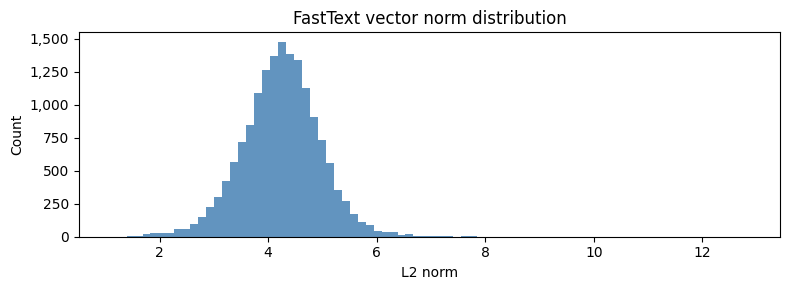

In [4]:
# Vector norm distribution for all FastText keys
norms = np.linalg.norm(ft.wv.vectors, axis=1)
print(f'Vector norms — mean: {norms.mean():.3f}  std: {norms.std():.3f}  '
      f'min: {norms.min():.3f}  max: {norms.max():.3f}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(norms, bins=80, color='steelblue', edgecolor='none', alpha=0.85)
ax.set_xlabel('L2 norm')
ax.set_ylabel('Count')
ax.set_title('FastText vector norm distribution')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig(VIZ_DIR / 'nb04_ft_norms.png', dpi=120)
plt.show()

## Section C — Embedding Matrix Coverage

In [5]:
matrix = np.load(str(MATRIX_PATH))
print(f'Matrix shape: {matrix.shape}  dtype: {matrix.dtype}')

if S8_STATS_PATH.exists():
    s8 = json.loads(S8_STATS_PATH.read_text())
    n_filled = s8.get('n_filled', '?')
    n_random = s8.get('n_random', '?')
    v_size   = s8.get('vocab_size', vocab_size)
    pct      = 100 * n_filled / v_size if isinstance(n_filled, int) else '?'
    print(f'\nCoverage from stage8_stats.json:')
    print(f'  Trained vectors : {n_filled:,} / {v_size:,}  ({pct:.1f}%)')
    print(f'  Random-init OOV : {n_random:,}')
    for k, v in s8.items():
        if k not in ('n_filled', 'n_random', 'vocab_size'):
            print(f'  {k:<30} {v}')

Matrix shape: (16000, 300)  dtype: float32

Coverage from stage8_stats.json:
  Trained vectors : 15,999 / 16,000  (100.0%)
  Random-init OOV : 0
  stage                          8
  embed_dim                      300
  pad_row_sum                    0.0
  matrix_shape                   [16000, 300]


In [6]:
# Per-row zero-check: a row is 'random-init' if its norm is below the 5th
# percentile of all norms (FastText trained vectors are rarely near-zero)
row_norms = np.linalg.norm(matrix, axis=1)
threshold = np.percentile(row_norms[4:], 5)   # skip special tokens (ids 0-3)
oov_mask  = row_norms < threshold

print(f'Low-norm (likely random-init) rows: {oov_mask.sum():,} '
      f'({100*oov_mask.mean():.1f}%)')
print(f'\nTop-10 lowest-norm token IDs:')
for idx in np.argsort(row_norms)[:10]:
    piece = sp.id_to_piece(int(idx))
    print(f'  id={idx:5d}  norm={row_norms[idx]:.4f}  piece={piece!r}')

Low-norm (likely random-init) rows: 804 (5.0%)

Top-10 lowest-norm token IDs:
  id=    0  norm=0.0000  piece='<pad>'
  id=    7  norm=1.0494  piece='__cmd__'
  id=15959  norm=1.1003  piece='▁'
  id=15987  norm=1.2737  piece="'"
  id=    3  norm=1.3553  piece='<eos>'
  id=   33  norm=1.4084  piece='▁.'
  id=15966  norm=1.5052  piece='s'
  id=    2  norm=1.5322  piece='<sos>'
  id=15982  norm=1.5350  piece='.'
  id=15983  norm=1.6714  piece='-'


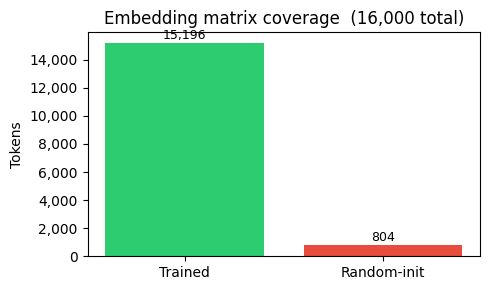

In [7]:
# Coverage bar chart
n_oov = int(oov_mask.sum())
n_cov = vocab_size - n_oov
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['Trained', 'Random-init'], [n_cov, n_oov],
       color=['#2ecc71', '#e74c3c'], edgecolor='none')
ax.set_ylabel('Tokens')
ax.set_title(f'Embedding matrix coverage  ({vocab_size:,} total)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar, val in zip(ax.patches, [n_cov, n_oov]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(VIZ_DIR / 'nb04_coverage.png', dpi=120)
plt.show()

## Section D — Token Fertility

In [8]:
SAMPLE_N = 5000
SEED     = 42
rng = random.Random(SEED)

# Sample from train JSONL
lines = TRAIN_JSONL.read_text().splitlines()
sample = rng.sample(lines, min(SAMPLE_N, len(lines)))

tok_counts, word_counts, char_counts = [], [], []
for line in sample:
    rec = json.loads(line)
    for key in ('ctx', 'resp'):
        ids = rec.get(key, [])
        if not ids:
            continue
        text = sp.decode(ids)  # decode token IDs back to text
        words = text.split()
        toks  = sp.encode(text, out_type=str)
        if words:
            word_counts.append(len(words))
            tok_counts.append(len(toks))
            char_counts.append(sum(len(w) for w in words))

avg_tpw = sum(tok_counts) / max(sum(word_counts), 1)
avg_cpt = sum(char_counts) / max(sum(tok_counts), 1)
print(f'Sample size           : {len(sample):,} pairs')
print(f'Avg tokens / word     : {avg_tpw:.3f}   (healthy: 1.2–1.8)')
print(f'Avg chars  / token    : {avg_cpt:.2f}')
if not (1.0 <= avg_tpw <= 2.5):
    print(f'  ⚠  Fertility {avg_tpw:.3f} outside [1.0, 2.5] — check SPM vocab')
else:
    print(f'  ✓  Fertility within normal range')

Sample size           : 5,000 pairs
Avg tokens / word     : 1.126   (healthy: 1.2–1.8)
Avg chars  / token    : 3.72
  ✓  Fertility within normal range


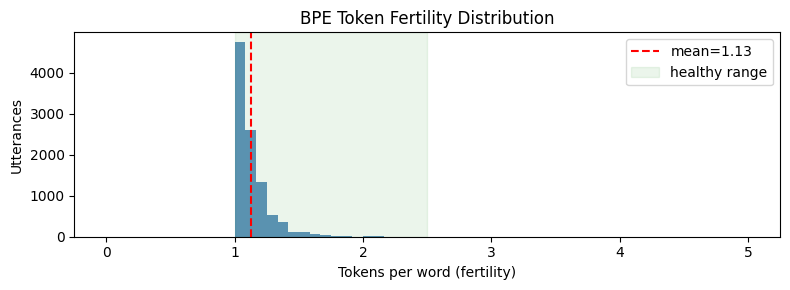

In [9]:
# Per-utterance fertility distribution
fertilities = [t / max(w, 1) for t, w in zip(tok_counts, word_counts)]
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(fertilities, bins=60, range=(0, 5), color='steelblue',
        edgecolor='none', alpha=0.85)
ax.axvline(avg_tpw, color='red', linestyle='--', label=f'mean={avg_tpw:.2f}')
ax.axvspan(1.0, 2.5, alpha=0.08, color='green', label='healthy range')
ax.set_xlabel('Tokens per word (fertility)')
ax.set_ylabel('Utterances')
ax.set_title('BPE Token Fertility Distribution')
ax.legend()
plt.tight_layout()
plt.savefig(VIZ_DIR / 'nb04_fertility.png', dpi=120)
plt.show()

## Section E — Nearest-Neighbour Sanity Checks

In [10]:
# Probe words: common Ubuntu / IRC vocabulary
PROBES = ['sudo', 'kernel', 'install', 'error', 'help', 'apt', 'bash', 'python']

for word in PROBES:
    # FastText uses ▁-prefixed pieces (sentencepiece style)
    piece = '\u2581' + word   # U+2581 = ▁
    if piece not in ft.wv:
        # try without prefix
        piece = word
    if piece in ft.wv:
        neighbours = ft.wv.most_similar(piece, topn=5)
        nn_str = ', '.join(f'{w!r}({s:.2f})' for w, s in neighbours)
        print(f'  {word:<12} → {nn_str}')
    else:
        # FastText can still infer OOV vectors via character n-grams
        vec = ft.wv.get_vector(word)
        neighbours = ft.wv.similar_by_vector(vec, topn=5)
        nn_str = ', '.join(f'{w!r}({s:.2f})' for w, s in neighbours)
        print(f'  {word:<12} (OOV inference) → {nn_str}')

  sudo         → 'sudo'(0.56), 'get'(0.51), '▁su'(0.50), '▁gksudo'(0.50), '▁-'(0.50)
  kernel       → '▁kernal'(0.78), '▁kernels'(0.73), '▁2.6.24'(0.58), '▁2.6.35'(0.57), '▁2.6.11'(0.57)
  install      → '▁instal'(0.72), '▁installing'(0.70), '▁installl'(0.70), '▁isntall'(0.67), '▁installe'(0.66)
  error        → '▁message'(0.70), '▁errors'(0.65), '▁eror'(0.63), '▁erro'(0.61), '▁errror'(0.60)
  help         → '▁assistance'(0.68), '▁assist'(0.65), '▁guidance'(0.58), '▁helping'(0.55), '▁helpme'(0.53)
  apt          → 'get'(0.81), '▁aptitude'(0.75), '▁autoremove'(0.56), 'cache'(0.55), '▁packagename'(0.53)
  bash         → '▁shell'(0.68), '▁scripting'(0.63), '▁shellscript'(0.61), 'bash'(0.58), '▁zsh'(0.58)
  python       → '▁perl'(0.68), '▁ruby'(0.67), 'python'(0.66), '2.4-'(0.63), 'ython'(0.61)


In [11]:
# Check that special placeholders have non-trivial embeddings
PLACEHOLDERS = ['__url__', '__path__', '__ip__', '__cmd__', '__number__', '__eot__']
print('Placeholder embedding norms in matrix:')
for ph in PLACEHOLDERS:
    ph_id = sp.piece_to_id(ph)
    unk_id = sp.piece_to_id('<unk>')
    if ph_id == unk_id:
        print(f'  {ph:<20} id=UNK  *** FRAGMENTED — not in SPM vocab ***')
        continue
    norm = float(np.linalg.norm(matrix[ph_id]))
    print(f'  {ph:<20} id={ph_id:4d}  matrix_norm={norm:.4f}')

Placeholder embedding norms in matrix:
  __url__              id=   4  matrix_norm=2.9664
  __path__             id=   5  matrix_norm=2.4547
  __ip__               id=   6  matrix_norm=4.1019
  __cmd__              id=   7  matrix_norm=1.0494
  __number__           id=   8  matrix_norm=1.8292
  __eot__              id=   9  matrix_norm=1.8930


## Section F — UNK Forensics

In [12]:
from collections import Counter

UNK_ID   = sp.piece_to_id('<unk>')
SAMPLE_N = 20_000
TOP_K    = 20

rng = random.Random(SEED)
lines = TRAIN_JSONL.read_text().splitlines()
sample = rng.sample(lines, min(SAMPLE_N, len(lines)))

total_tokens = 0
unk_count    = 0
unk_triggers = Counter()

for line in sample:
    rec = json.loads(line)
    for seq_key in ('ctx', 'resp'):
        ids = rec.get(seq_key, [])
        total_tokens += len(ids)
        unk_count    += ids.count(UNK_ID)
        text = sp.decode(ids)  # decode token IDs back to text
        for word in text.split():
            if UNK_ID in sp.encode(word, out_type=int):
                unk_triggers[word] += 1

unk_rate = unk_count / max(total_tokens, 1)
print(f'Sample            : {len(sample):,} pairs')
print(f'Total tokens      : {total_tokens:,}')
print(f'UNK count         : {unk_count:,}')
print(f'UNK rate          : {unk_rate:.2e}')
if unk_rate > 1e-3:
    print('  ⚠  UNK rate > 0.1% — investigate top triggers below')
else:
    print('  ✓  UNK rate within acceptable range')
print(f'\nTop {TOP_K} UNK-triggering words:')
for word, cnt in unk_triggers.most_common(TOP_K):
    print(f'  {word:<30} {cnt:>6,}')

Sample            : 20,000 pairs
Total tokens      : 1,519,058
UNK count         : 0
UNK rate          : 0.00e+00
  ✓  UNK rate within acceptable range

Top 20 UNK-triggering words:


## Section G — Stage 8 Stats Summary

In [13]:
if S8_STATS_PATH.exists():
    s8 = json.loads(S8_STATS_PATH.read_text())
    print('stage8_stats.json:')
    for k, v in s8.items():
        print(f'  {k:<35} {v}')
else:
    print('stage8_stats.json not found — run Stage 8 first')

stage8_stats.json:
  stage                               8
  vocab_size                          16000
  embed_dim                           300
  n_filled                            15999
  n_random                            0
  pad_row_sum                         0.0
  matrix_shape                        [16000, 300]


In [14]:
print('=' * 60)
print('NB04 SUMMARY')
print('=' * 60)
print(f'  SPM vocab size      : {vocab_size:,}')
print(f'  FastText vocab size : {ft_vocab:,}')
print(f'  Embedding dim       : {embed_dim}')
print(f'  Matrix shape        : {matrix.shape}')
print(f'  Avg fertility       : {avg_tpw:.3f} tok/word')
print(f'  UNK rate            : {unk_rate:.2e}')
if S8_STATS_PATH.exists():
    s8 = json.loads(S8_STATS_PATH.read_text())
    pct = 100 * s8.get('n_filled', 0) / max(s8.get('vocab_size', 1), 1)
    print(f'  Embedding coverage  : {pct:.1f}%')
print('=' * 60)

NB04 SUMMARY
  SPM vocab size      : 16,000
  FastText vocab size : 15,980
  Embedding dim       : 300
  Matrix shape        : (16000, 300)
  Avg fertility       : 1.126 tok/word
  UNK rate            : 0.00e+00
  Embedding coverage  : 100.0%
